
✅ Test Accuracy: 0.8775

📊 Classification Report:
              precision    recall  f1-score   support

       anger       0.89      0.86      0.88       275
        fear       0.86      0.88      0.87       224
         joy       0.86      0.93      0.89       695
        love       0.80      0.69      0.74       159
     sadness       0.94      0.91      0.93       581
    surprise       0.64      0.64      0.64        66

    accuracy                           0.88      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.88      0.88      0.88      2000



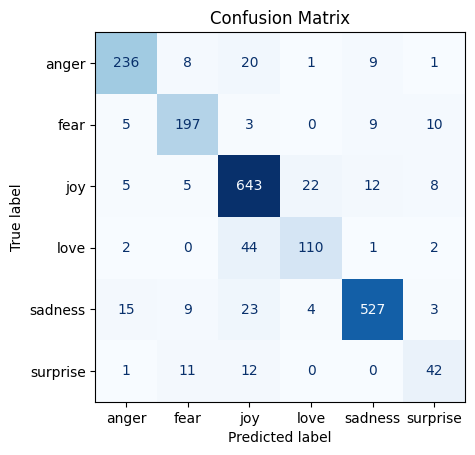


💾 Model and vectorizer saved successfully as:
 - random_forest_model.pkl
 - tfidf_vectorizer.pkl


In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import joblib
import matplotlib.pyplot as plt

# Function to read text and labels from a file
def read_text_label(path):
    texts = []
    labels = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if ';' not in line:
                continue
            text, label = line.rsplit(';', 1)
            texts.append(text)
            labels.append(label)
    return pd.DataFrame({'text': texts, 'label': labels})

# Load datasets
train_df = read_text_label('train.txt')
val_df = read_text_label('val.txt')
test_df = read_text_label('test.txt')

# Combine train and validation data
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_val = vectorizer.fit_transform(train_val_df['text'])
y_train_val = train_val_df['label']

# Transform test data
X_test = vectorizer.transform(test_df['text'])
y_test = test_df['label']

# Train Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_val, y_train_val)

# Predict on test set
y_pred = clf.predict(X_test)

# Evaluate model
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy: {accuracy:.4f}\n")

print("📊 Classification Report:")
print(metrics.classification_report(y_test, y_pred))

# Confusion Matrix
cm_display = metrics.ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, cmap='Blues', colorbar=False
)
plt.title("Confusion Matrix")
plt.show()

# Save model and vectorizer
joblib.dump(clf, 'random_forest_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("\n💾 Model and vectorizer saved successfully as:")
print(" - random_forest_model.pkl")
print(" - tfidf_vectorizer.pkl")
